In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

In [62]:
def generate_multivariate_sine_projected(T, d, latent_dim=3):
    t = np.linspace(0, 1, T)
    
    # 1. Generate K independent hidden signals
    latent_signals = np.zeros((T, latent_dim))
    for k in range(latent_dim):
        freq = np.random.uniform(2, 5) * (k + 1) # Distinct frequencies
        phase = np.random.uniform(0, 2*np.pi)
        latent_signals[:, k] = np.sin(2 * np.pi * freq * t + phase)
        
    # 2. Create a fixed Mixing Matrix (latent_dim x d)
    # This maps the 3 hidden signals to your 15 observed channels
    mixing_matrix = np.random.uniform(-1, 1, (latent_dim, d))
    
    # 3. Project the signals: (T x 3) @ (3 x 15) = (T x 15)
    X = latent_signals @ mixing_matrix
    
    # Add independent channel noise
    noise = np.random.normal(0, 0.1, (T, d))
    X = X + noise
    return X

def generate_multivariate_trend(T, d):
    t = np.linspace(0,1,T)
    base_a = np.random.uniform(0.05,0.5)
    base_b = np.random.uniform(-0.5,0.5)
    
    X = np.zeros((T, d))
    
    # Pre-determine which channels have positive/negative correlation to the base
    correlations = np.random.choice([1, -1], size=d)

    for j in range(d):
        # Some channels go up, some go down, but the slope magnitude is locked
        channel_signal = (base_a * correlations[j]) * t + base_b   
        noise = np.random.normal(0, 0.07, T)
        X[:, j] = channel_signal + noise

    return X

def generate_multivariate_var(T, d):
    X = np.zeros((T, d))
    
    # 1. Create a sparse transition matrix A
    # The diagonal is self-dependence, off-diagonals are cross-channel dependence
    A = np.eye(d) * np.random.uniform(0.5, 0.8, d) 
    
    # Add some random cross-channel dependencies
    for _ in range(d):
        i, j = np.random.randint(0, d, 2)
        if i != j:
            A[i, j] = np.random.uniform(-0.3, 0.3)
            
    # Ensure stability (eigenvalues must be < 1)
    eigenvalues = np.linalg.eigvals(A)
    max_eig = np.max(np.abs(eigenvalues))
    if max_eig >= 1:
        A = A / (max_eig + 0.01)

    # 2. Generate the sequence
    noise = np.random.normal(0, 0.4, (T, d))
    for t in range(1, T):
        X[t] = A @ X[t-1] + noise[t]

    X = gaussian_filter1d(X, sigma=1, axis=0)    
        
    return X, A

def inject_var_anomaly(X, start, length, A_original):
    A_anomaly = A_original.copy()
    d = X.shape[1]
    for _ in range(2): # Inject 3 random anomalies in the transition matrix
        i, j = np.random.randint(0, d, 2)
        if i != j:
            A_anomaly[i, j] = -A_anomaly[i,j]

    eigenvalues = np.linalg.eigvals(A_anomaly)
    max_eig = np.max(np.abs(eigenvalues))
    if max_eig >= 1:
        A_anomaly = A_anomaly / (max_eig + 0.01)
        
    for t in range(start, start + length):
        X[t] = A_anomaly @ X[t-1] + np.random.normal(0, 0.4, d) 
    return X

def inject_trend_intrusion(X, start, length):
    d = X.shape[1]
    intrusion = generate_multivariate_sine_projected(length, d)
    intrusion *= 0.2
    shift = X[start - 1, :] - intrusion[0, :]
    X[start:start+length, :] = intrusion + shift
    return X

def inject_sine_anomaly_channel(X, start, length):
    d = X.shape[1]
    segment = X[start:start+length, :].copy()
    
    num_affected = np.random.randint(1, 4) # Alter 1 to 3 channels
    affected_channels = np.random.choice(d, num_affected, replace=False)
    
    for j in affected_channels:
        segment[:, j] *= np.random.uniform(1.2, 1.5) 
        
        drift = np.linspace(0, np.random.uniform(-0.4, 0.4), length)
        segment[:, j] += drift
    
    segment += np.random.normal(0, 0.02, (length, d))
    
    X[start:start+length, :] = segment
    return X

def generate_timeseries(T=200000, 
                        d=15, 
                        train_ratio=0.7,
                        anomaly_length = 300, 
                        num_segments = 8):
    #Define how many segments we want and their length
    segment_length = T // num_segments
    # Define how much training data we want
    train_end = int(T * train_ratio)

    #--------------------------------------
    #Generate segments of different regimes
    #--------------------------------------
    X1 = generate_multivariate_trend(segment_length, d)
    X2 = generate_multivariate_sine_projected(segment_length, d)
    X3, A3 = generate_multivariate_var(segment_length, d)
    X4 = generate_multivariate_sine_projected(segment_length, d)
    X5 = generate_multivariate_trend(segment_length, d)
    X6 = generate_multivariate_sine_projected(segment_length, d)
    X7, A7 = generate_multivariate_var(segment_length, d)
    X8 = generate_multivariate_trend(segment_length, d)


    #Create labels (all normal to start)
    y_segments = [np.zeros(segment_length) for _ in range(num_segments)]

    #-----------------
    # Inject anomalies
    #-----------------
    anomaly_starts_global = []
    for _ in range(4): 
        anomaly_length = np.random.randint(200, 450)
        start = np.random.randint(0, segment_length - anomaly_length)
        X7 = inject_var_anomaly(X7, start, anomaly_length, A7)
        y_segments[6][start:start+anomaly_length] = 1 
        anomaly_starts_global.append((6 * segment_length) + start)

    # Inject 4 Regime Intrusion anomalies
    for _ in range(4):
        anomaly_length = np.random.randint(50, 150)
        start = np.random.randint(0, segment_length - anomaly_length)
        X8 = inject_trend_intrusion(X8, start, anomaly_length)
        y_segments[7][start:start+anomaly_length] = 1
        anomaly_starts_global.append((7 * segment_length) + start)


    safe_start_idx = train_end - (5 * segment_length)
    anomaly_length = np.random.randint(50, 150)
    start = np.random.randint(safe_start_idx, segment_length - anomaly_length)
    X6 = inject_sine_anomaly_channel(X6, start, anomaly_length)
    y_segments[5][start:start+anomaly_length] = 1
    anomaly_starts_global.append((5 * segment_length) + start)
    
    # align segments
    def align(prev, curr):
        shift = prev[-1] - curr[0]
        return curr + shift

    X2 = align(X1, X2)
    X3 = align(X2, X3)
    X4 = align(X3, X4)
    X5 = align(X4, X5)
    X6 = align(X5, X6)
    X7 = align(X6, X7)
    X8 = align(X7, X8)

    #Combine all segments
    X = np.vstack([X1, X2, X3, X4, X5, X6, X7, X8])    
    y = np.concatenate(y_segments)

    first_anomaly_start = min(anomaly_starts_global)
    return X, y, first_anomaly_start

In [66]:
def plot_mts(X, y): #, regimes):
    T, d = X.shape
    t = np.arange(T)
    
    fig, axes = plt.subplots(5, 1, figsize=(20, 10), sharex=True)
    
    if d == 1:
        axes = [axes]
    
    for j in range(5):
        axes[j].plot(t, X[:, j])
        
        # # Highlight anomalies
        # anomaly_idx = np.where(y == 1)[0]
        # axes[j].scatter(anomaly_idx, X[anomaly_idx, j], s=10)
        
        # axes[j].set_ylabel(f"Channel {j}")
    
    
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

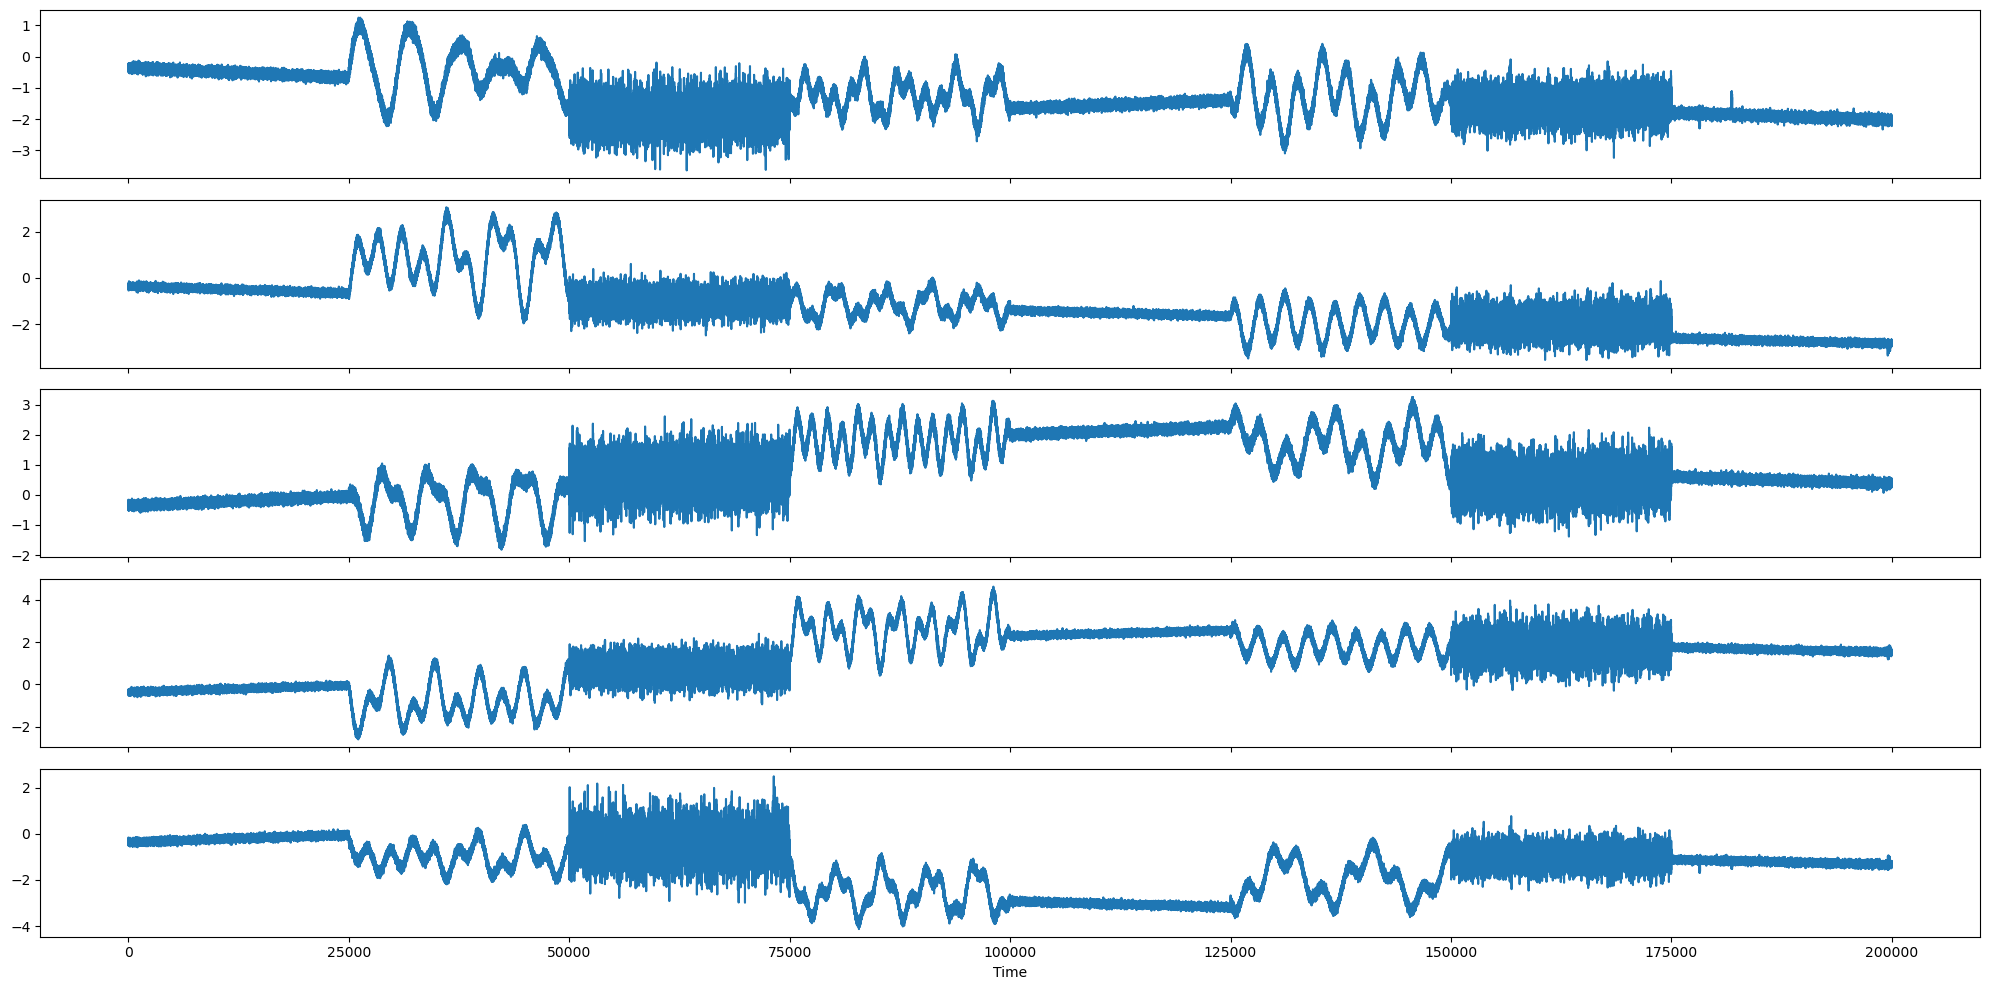

In [72]:
X,y,starts = generate_timeseries()
plot_mts(X,y)

In [77]:
#-------------------------
#Create Tuning Dataset
#-------------------------
tuning_filenames = ['file_name']
for i in range(15,20):
    np.random.seed(23 + i)
    X,y,start = generate_timeseries()
    filename = f"{i+1}_TuningMixedRegimes_id_{i}_Sensor_tr_140000_1st_{start}.csv"
    tuning_filenames.append(filename)
    df = pd.DataFrame(X, columns=[f"Channel_{j}" for j in range(X.shape[1])])
    df['Label'] = y
    df.to_csv(filename, index=False)

import csv
with open('my-data-Tuning.csv', 'w', newline='') as file:
    writer = csv.writer(file)

    for name in tuning_filenames:
        writer.writerow([name])

In [ ]:
#-------------------------
#Create evaluation dataset
#-------------------------
filenames = ['file_name']

for i in range(0,15):
    np.random.seed(42 + i)
    X,y,start = generate_timeseries()
    filename = f"{i+1}_MixedRegimes_id_{i}_Sensor_tr_140000_1st_{start}.csv"
    filenames.append(filename)
    df = pd.DataFrame(X, columns=[f"Channel_{j}" for j in range(X.shape[1])])
    df['Label'] = y
    df.to_csv(filename, index=False)

import csv
with open('my-data-Eva.csv', 'w', newline='') as file:
    writer = csv.writer(file)

    for name in filenames:
        writer.writerow([name])

In [64]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score

# Generate data
X, y, starts = generate_timeseries()

# Fit Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.02,  # expected anomaly proportion
    random_state=42
)

iso.fit(X)

# Predict
preds = iso.predict(X)

# Convert predictions:
# sklearn: -1 = anomaly, 1 = normal
y_pred = (preds == -1).astype(int)

# Evaluate
print("Classification Report:")
print(classification_report(y, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99    198246
         1.0       0.00      0.00      0.00      1754

    accuracy                           0.97    200000
   macro avg       0.50      0.49      0.49    200000
weighted avg       0.98      0.97      0.98    200000



In [65]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

# 1. Fit PCA to find the linear spatial components
# We will reduce your 15 channels down to 5 underlying dimensions
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X)

# 2. Project back to 15 dimensions to see how well it learned the rules
X_reconstructed = pca.inverse_transform(X_pca)

# 3. Calculate the Reconstruction Error per timestep
# We take the mean squared difference across all 15 channels
reconstruction_error = np.mean((X - X_reconstructed)**2, axis=1)

# 4. Thresholding
# Since we know your anomaly rate is roughly 0.8% (1754 / 200000),
# we will give PCA a fair fight and explicitly flag the top 1% of errors.
threshold = np.percentile(reconstruction_error, 99)
y_pred_pca = (reconstruction_error > threshold).astype(int)

# 5. Evaluate
print("PCA Reconstruction Error Report:")
print(classification_report(y, y_pred_pca))

PCA Reconstruction Error Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99    198246
         1.0       0.02      0.03      0.02      1754

    accuracy                           0.98    200000
   macro avg       0.51      0.51      0.51    200000
weighted avg       0.98      0.98      0.98    200000

